In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:


# print(plt.style.available)
# plt.style.use('seaborn-v0_8')
plt.style.use('default')

# plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['xtick.labelsize'] = 20
# plt.rcParams['xtick.major.size'] = 3
# plt.rcParams['xtick.major.width'] = 2
# plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.labelsize'] = 20
# plt.rcParams['ytick.major.width'] = 1
# plt.rcParams['ytick.minor.size'] = 5
# plt.rcParams['figure.figsize'] =  (30, 30)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
# plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.grid'] = False
plt.rcParams['xtick.bottom'] = True  # Turn on xticks
plt.rcParams['ytick.left'] = True
# Resolution
# Legend Parameters
plt.rcParams['figure.dpi'] = 300
plt.rcParams['legend.fontsize'] = 16
# plt.rcParams['lines.markersize'] = 14

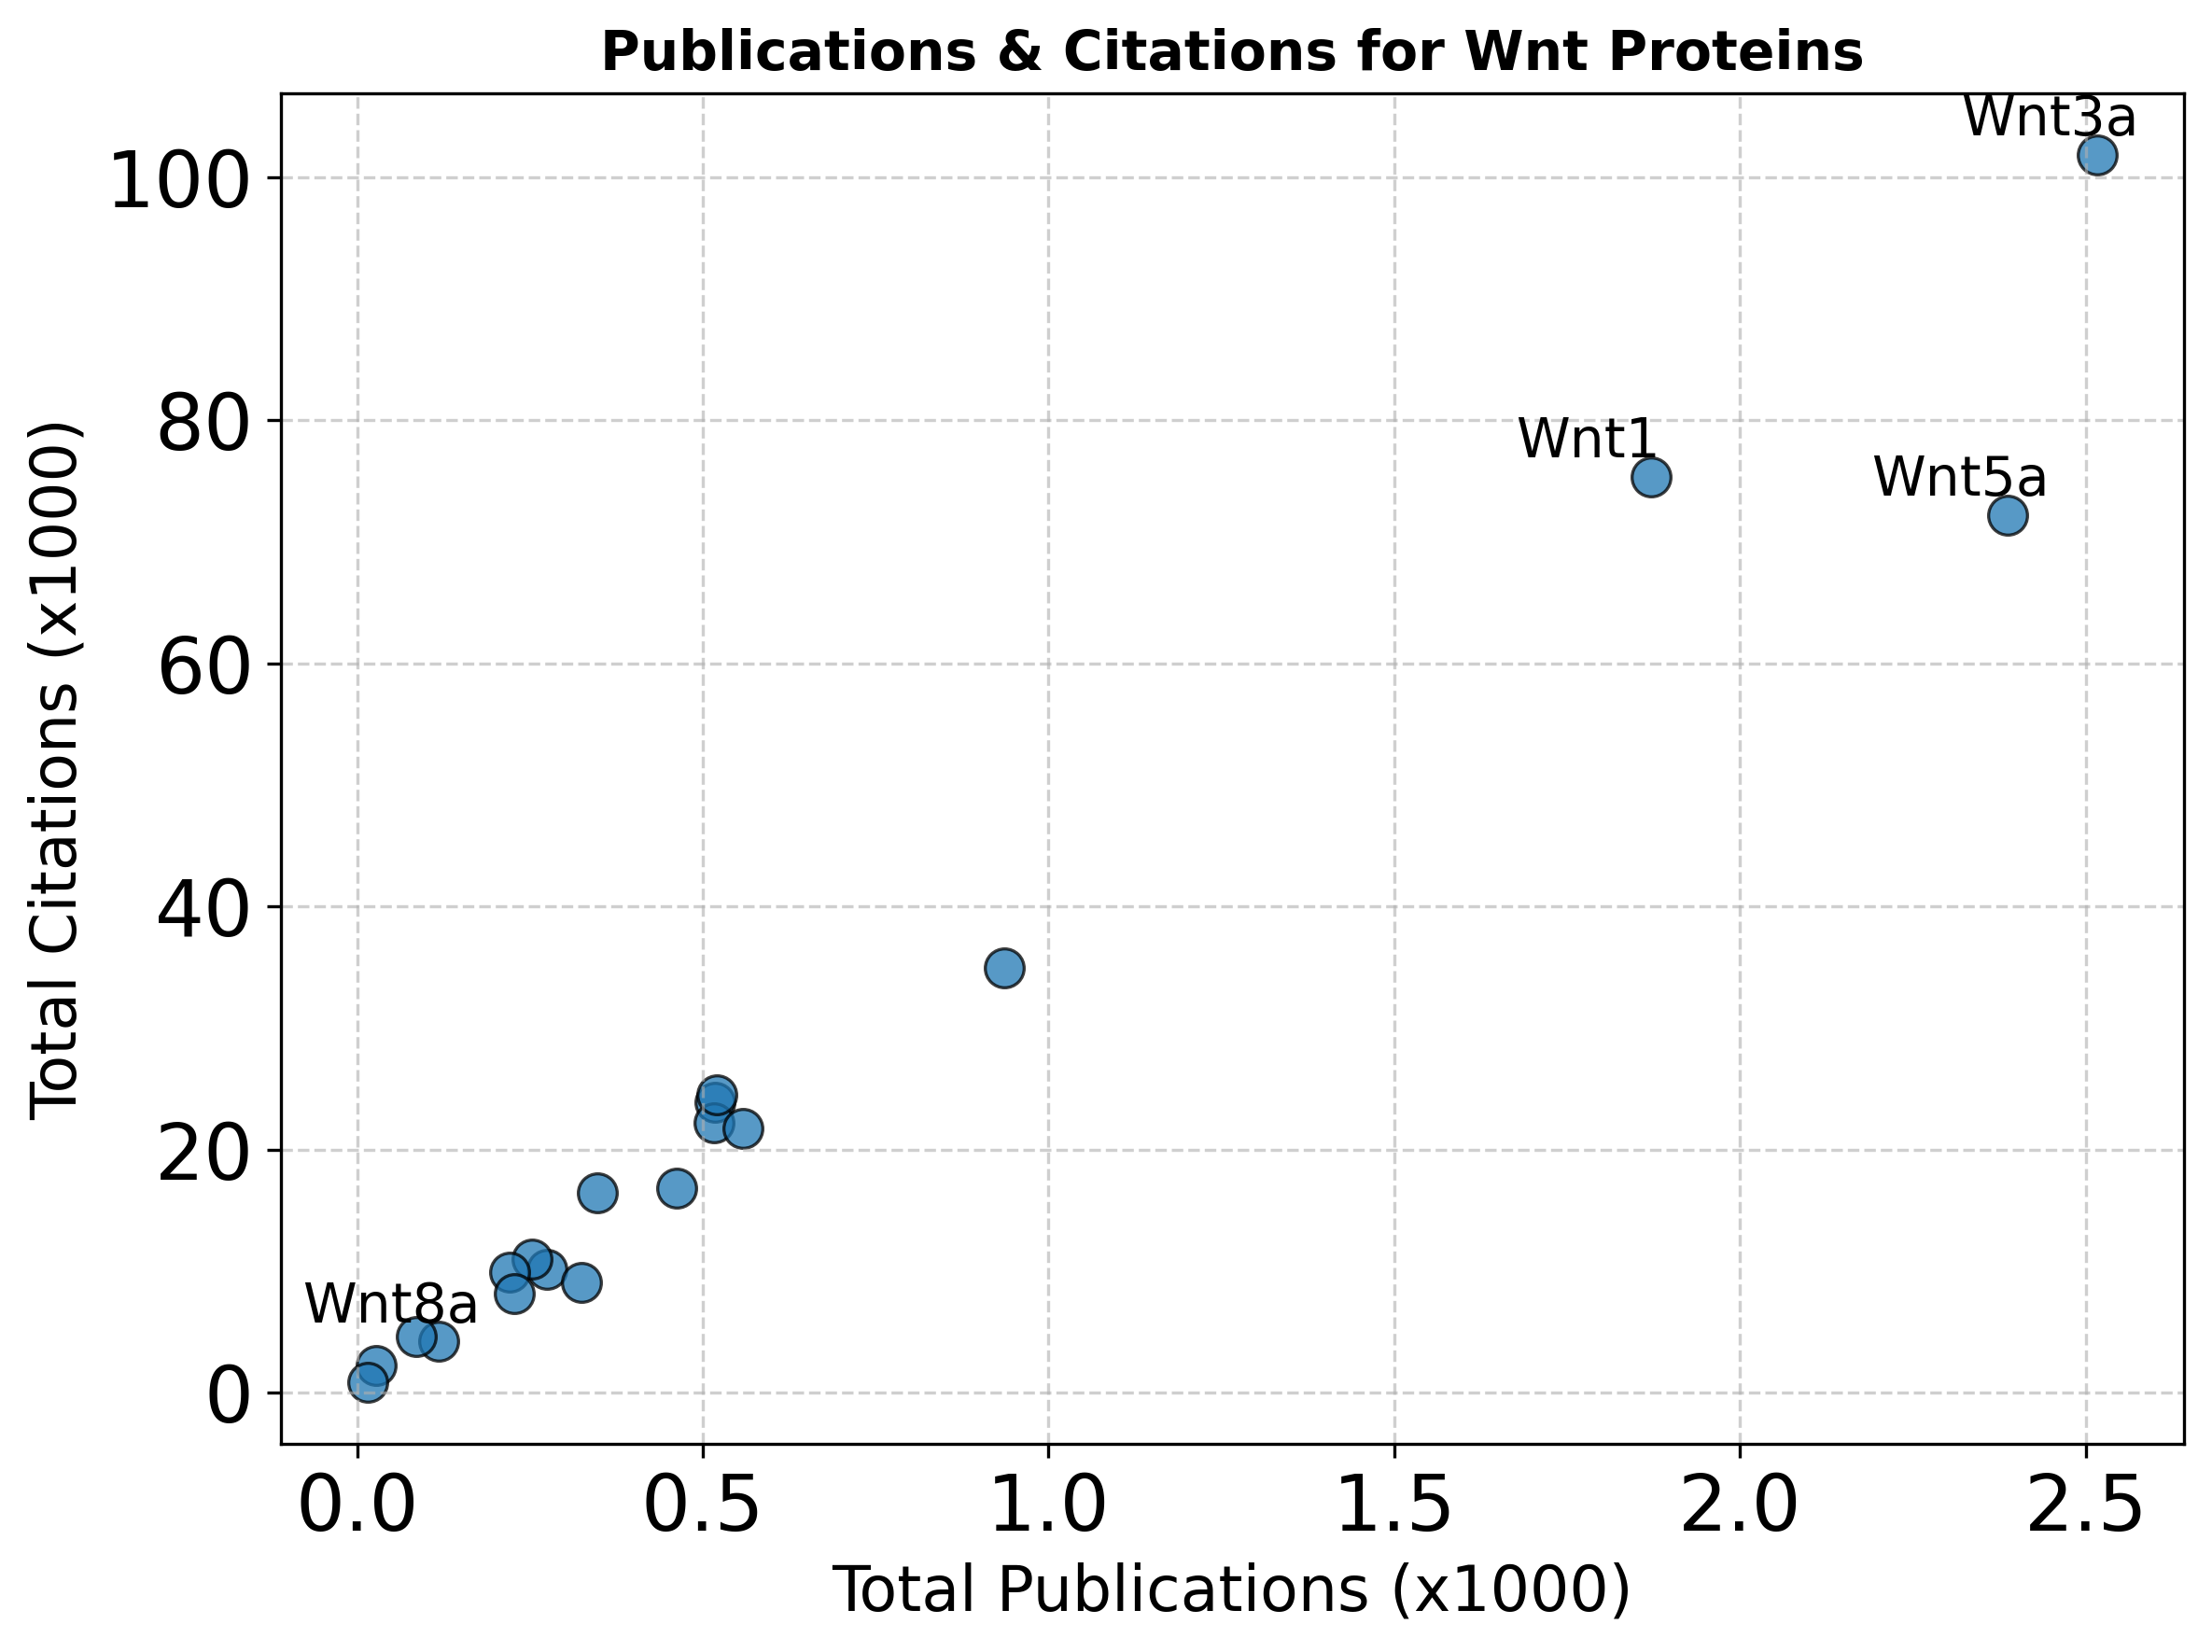

In [3]:


# Data from your figurea
wnt_proteins = ["Wnt1", "Wnt2", "Wnt2b/13", "Wnt3", "Wnt3a", "Wnt4", "Wnt5a", "Wnt5b", "Wnt6",
                "Wnt7a", "Wnt7b", "Wnt8a", "Wnt8b", "Wnt10a", "Wnt10b/12", "Wnt11", "Wnt14", "Wnt15", "Wnt16"]

scaling_factor = 1000

publications = np.array([1872, 462, 274, 517, 2517, 936, 2387, 253,
                221, 516, 347, 118, 86, 324, 558, 520, 28, 15, 227])/scaling_factor
citations = np.array([75333, 16849, 10136, 23853, 101826, 34917, 72186, 11004,
             9949, 22179, 16418, 4205, 4606, 9076, 21737, 24529, 2207, 824, 8122])/scaling_factor

h_index = np.array([128,70,58,81,144,99,128,59,56,82,74,37,40,54,77,84,22,14,52])  


# Year of peak publication from your new figure
peak_year = np.array([2019, 2021, 2021, 2021, 2022, 2021,
                     2020, 2020, 2021, 2017, 2002, 2021, 2019, 2002, 2002, 2018])


# # Normalize H-index for better scaling in marker size
# h_scaled = 50 + (h_index - min(h_index)) / (max(h_index) -
#                                             min(h_index)) * 250  # Marker size range from 50 to 300


# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot

sns.scatterplot(x=publications, y=citations, s=100,
                alpha=0.75, edgecolor='black')

# Scatter plot with marker size = H-index
# sns.scatterplot(x=publications, y=citations, s=h_scaled,
#                 alpha=0.75, edgecolor='black')


# # Regression line
sns.regplot(x=publications, y=citations, scatter=False,
            ci=None, color='red', line_kws={'linewidth': 2}, fit_reg=False)

# Labels and titles
ax.set_xlabel(f"Total Publications (x{scaling_factor})")
ax.set_ylabel(f"Total Citations (x{scaling_factor})")
ax.set_title("Publications & Citations for Wnt Proteins",
             fontsize=14, fontweight='bold')



# Annotate data points
# for i, txt in enumerate(wnt_proteins):
for txt in ["Wnt3a", "Wnt5a", "Wnt1", "Wnt8a"]:
    i = wnt_proteins.index(txt)
    ax.annotate(txt, (publications[i], citations[i]), fontsize=14, xytext=(
        -35, 5), textcoords="offset points")

# Improve layout
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

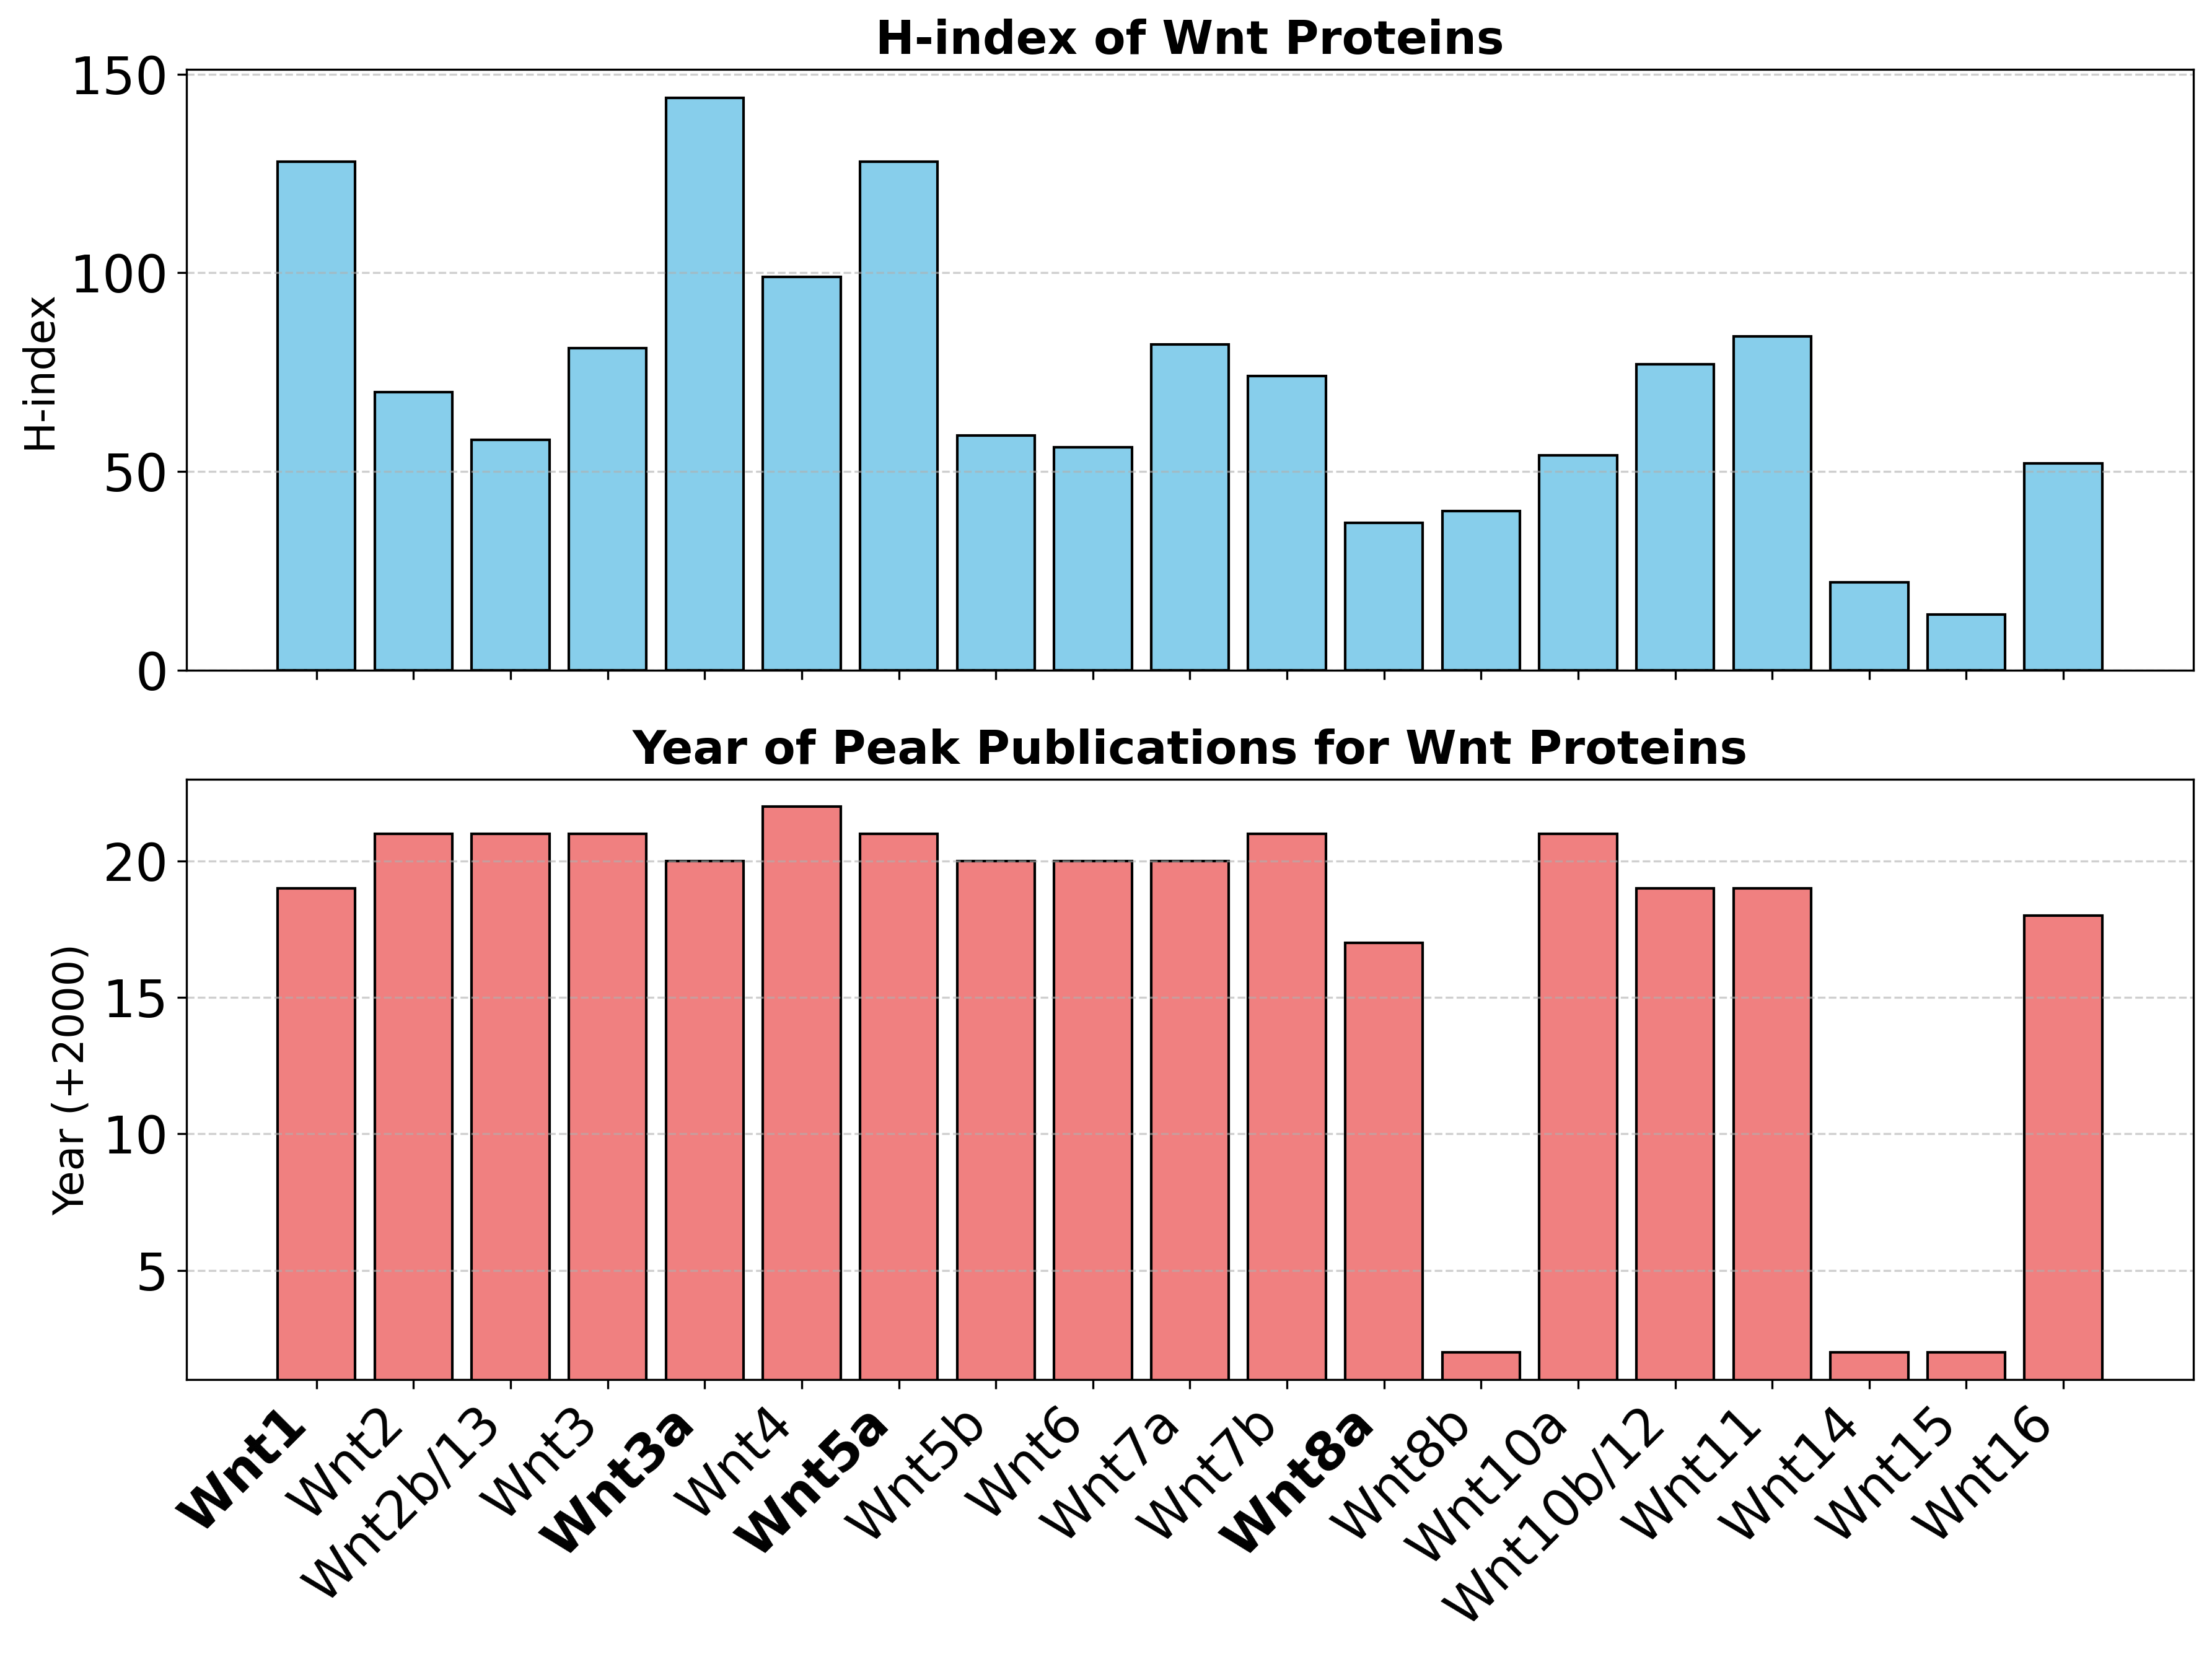

In [4]:
import numpy as np
import matplotlib.pyplot as plt
wnt_proteins = ["Wnt1", "Wnt2", "Wnt2b/13", "Wnt3", "Wnt3a", "Wnt4", "Wnt5a", "Wnt5b", "Wnt6",
                "Wnt7a", "Wnt7b", "Wnt8a", "Wnt8b", "Wnt10a", "Wnt10b/12", "Wnt11", "Wnt14", "Wnt15", "Wnt16"]
h_index = np.array([128, 70, 58, 81, 144, 99, 128, 59, 56,
                   82, 74, 37, 40, 54, 77, 84, 22, 14, 52])


# Year of peak publication from your new figure
peak_year = np.array([19, 21, 21, 21, 20, 22, 21,
                     20, 20, 20, 21, 17, 2, 21, 19, 19, 2, 2, 18])


# Check that lengths match
assert len(wnt_proteins) == len(h_index) == len(
    peak_year), "Array lengths must match!"

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Bar plot for H-index
axes[0].bar(wnt_proteins, h_index, color='skyblue', edgecolor='black')
axes[0].set_ylabel('H-index' )
axes[0].set_title('H-index of Wnt Proteins',  fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Bar plot for Peak Year
axes[1].bar(wnt_proteins, peak_year, color='lightcoral', edgecolor='black')
axes[1].set_ylabel('Year (+2000)', )
axes[1].set_ylim((1,23))
axes[1].set_title('Year of Peak Publications for Wnt Proteins',
                  fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)


# Bold specific x-axis tick labels (e.g., 'B' and 'D')
for label in axes[1].get_xticklabels():
    if label.get_text() in ["Wnt3a", "Wnt5a", "Wnt1", "Wnt8a"]:  # Change as needed
        label.set_fontweight('bold')

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Tight layout for clarity
plt.tight_layout()
plt.show()